In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch
import sys
from scipy import stats
from scipy.stats import norm
import pickle

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/')
from estimate_bayesian_fdr import *
from differential_splicing import *

In [3]:
# Main path set up
main_path="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/0209"

# List the directories in the main path
dirs = os.listdir(main_path)
# Which dirs have "NoCellType_Random" in them 
dirs = [d for d in dirs if "NoCellType_Random" in d]

['analysis_20250209_162201_PropNeg_0.9_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_1000_ConcPrior_inf_Inits_10_NoCellType_Random_99', 'analysis_20250209_162219_PropNeg_0.9_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_1000_LearnedConc_Inits_10_NoCellType_Random_25', 'analysis_20250209_162025_PropNeg_0.9_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_1000_LearnedConc_Inits_10_NoCellType_Random_88', 'analysis_20250209_161337_PropNeg_0.5_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_1000_ConcPrior_inf_Inits_10_NoCellType_Random_41', 'analysis_20250209_162622_PropNeg_0.9_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_1000_ConcPrior_inf_Inits_10_NoCellType_Random_55', 'analysis_20250209_161337_PropNeg_0.5_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_1000_LearnedConc_Inits_10_NoCellType_Random_43', 'analysis_20250209_161337_PropNeg_0.1_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_1000_LearnedConc_Inits_10_NoCellType_Random_66', 'analysis_20250209_161337_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPr

In [4]:
# Choose which simulation directory to analyze 
dir_analyze=dirs[9]
print(dir_analyze)

# Set up the path to the simulation directory
sim_dir=os.path.join(main_path,dir_analyze)

# Print the names of the files in the simulation directory
files = os.listdir(sim_dir)
print(files)

analysis_20250209_161337_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_1000_ConcPrior_inf_Inits_10_NoCellType_Random_77
['clustermap.png', 'losses.png', 'random_init_42442_loss_curve.png', 'assignment_correlations.png', 'est_deltapsi_vs_difference.png', 'pi_barplot.png', 'random_init_32820_loss_curve.png', 'nmf_clustermap.png', 'random_init_89670_loss_curve.png', 'nmf_umap.png.pdf', 'ALBF_scores.csv', 'a_b_params.pkl', 'random_init_20245_loss_curve.png', 'pi_df.csv', 'albf_vs_difference.png', 'random_init_77122_loss_curve.png', 'random_init_76183_loss_curve.png', 'cell_type_psi_df.csv', 'random_init_89687_loss_curve.png', 'final_results.csv', 'ALBF_report.txt', 'umap.png.pdf', 'roc_curve.png', 'est_deltapsi_vs_difference.pdf', 'parameters.json', 'precision_recall_curve.png', 'analysis_report.txt', 'random_init_91207_loss_curve.png', 'precision_recall_curve.pdf', 'random_init_61938_loss_curve.png', 'random_init_28896_loss_curve.png', 'ALBF_score_distribution.png']


In [5]:
sim_dir

'/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/0209/analysis_20250209_161337_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_1000_ConcPrior_inf_Inits_10_NoCellType_Random_77'

In [6]:
# Extract PropNeg_0.5 from sim_dir 
prop_neg = sim_dir.split("_")[-15]
print(prop_neg)

0.5


In [7]:
# Original PSI_df from simulation
PSI_df = pd.read_csv(os.path.join(sim_dir, "cell_type_psi_df.csv"))

# Load learned pis vector 
pis = pd.read_csv(os.path.join(sim_dir, "pi_df.csv"))
pis = pis.sort_values(by=['Factor'])
pis = pis["pi"].values

In [8]:
# open a, b prior pickle file a_b_params.pkl 
with open(os.path.join(sim_dir, "a_b_params.pkl"), 'rb') as f:
    a_b_params = pickle.load(f)

In [9]:
a = a_b_params['a']
b = a_b_params['b']

print(f"The latent variables a and b for prior on PSI are {a} and {b}")

The latent variables a and b for prior on PSI are 0.6326414346694946 and 1.1709861755371094


In [10]:
pis

array([0.49910346, 0.5008966 ])

(array([7319.,  474.,  165.,  101.,   66.,   49.,   49.,   43.,   34.,
          33.,   38.,   22.,   30.,   32.,   38.,   18.,   23.,   21.,
          22.,   25.,   22.,   14.,   19.,   19.,   16.,   30.,   29.,
          24.,   17.,   15.,   20.,   30.,   33.,   21.,   33.,   24.,
          19.,   33.,   17.,   39.,   28.,   31.,   43.,   50.,   54.,
          73.,   65.,  111.,  159., 6204.]),
 array([0.49996948, 0.50997009, 0.5199707 , 0.52997131, 0.53997192,
        0.54997253, 0.55997314, 0.56997375, 0.57997437, 0.58997498,
        0.59997559, 0.6099762 , 0.61997681, 0.62997742, 0.63997803,
        0.64997864, 0.65997925, 0.66997986, 0.67998047, 0.68998108,
        0.69998169, 0.7099823 , 0.71998291, 0.72998352, 0.73998413,
        0.74998474, 0.75998535, 0.76998596, 0.77998657, 0.78998718,
        0.79998779, 0.8099884 , 0.81998901, 0.82998962, 0.83999023,
        0.84999084, 0.85999146, 0.86999207, 0.87999268, 0.88999329,
        0.8999939 , 0.90999451, 0.91999512, 0.92999573, 

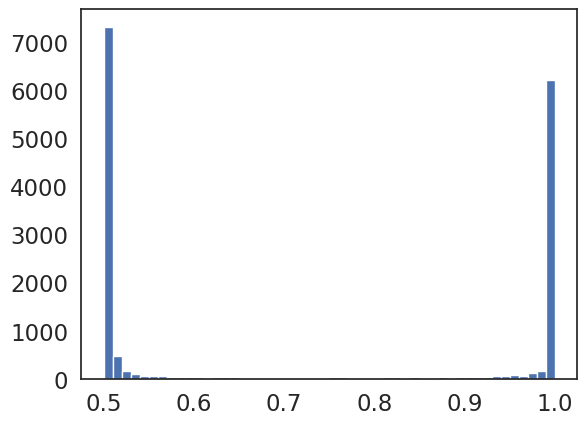

In [11]:
# let's load the final_results.csv file 
albf_scores = pd.read_csv(os.path.join(sim_dir, "ALBF_scores.csv"))

# rename the first two columns to be sim_psi_1 and sim_psi_2
albf_scores = albf_scores.rename(columns={"0": "latent_psi_1", "1": "latent_psi_2"})

# let's rename our true_label column according to the difference that was observed 
# if junction difference ended up being >= 0.2 then we will call it "True" 
# if junction difference ended up being < 0.2 then we will call it "False"
# use difference column 
albf_scores["true_label"] = "negative"
albf_scores.loc[albf_scores["difference"] >= 0.2, "true_label"] = "positive"

# calculate sigmoid on ALBF 
albf_scores["sigmoid_ALBF"] = 1 / (1 + np.exp(-albf_scores["ALBF"]))
# make histogram of sigmoid ALBF 
plt.hist(albf_scores["sigmoid_ALBF"], bins=50) # clearly bimodal from 0.5-1

In [12]:
# let's set up a dictionary to keep track of the results for tp, fp, tn, fn, fdr, fnr at each percentile along with what the ALBF cutoff is
em_results = {}

em = EMDifferentialSplicing(albf_scores["ALBF"], initial_p=0.1, max_iter=200)
results = em.fit()
albf_scores["posterior_probs"] = results["posterior_probs"]

Initial Statistics:
Original ALBF range: [-0.00, 1510.21]
b_j range: [0.0000, 1.0000]

Iteration 1:
p: 0.160322
log likelihood: -537.230897
q_s1 range: [0.000000, 1.000000]

Iteration 2:
p: 0.192071
log likelihood: -446.591251
q_s1 range: [0.000000, 1.000000]

Iteration 3:
p: 0.208599
log likelihood: -417.670945
q_s1 range: [0.000000, 1.000000]

Iteration 4:
p: 0.217172
log likelihood: -405.636325
q_s1 range: [0.000000, 1.000000]

Iteration 5:
p: 0.221613
log likelihood: -400.048536
q_s1 range: [0.000000, 1.000000]

Iteration 6:
p: 0.223911
log likelihood: -397.313062
q_s1 range: [0.000000, 1.000000]

Iteration 7:
p: 0.225101
log likelihood: -395.937623
q_s1 range: [0.000000, 1.000000]

Iteration 8:
p: 0.225716
log likelihood: -395.236481
q_s1 range: [0.000000, 1.000000]

Iteration 9:
p: 0.226035
log likelihood: -394.876533
q_s1 range: [0.000000, 1.000000]

Iteration 10:
p: 0.226199
log likelihood: -394.691069
q_s1 range: [0.000000, 1.000000]

Iteration 11:
p: 0.226284
log likelihood: 

In [13]:
FDR_ALBF = albf_scores[albf_scores["posterior_probs"] >= 0.95].sort_values(by="ALBF").iloc[0]["ALBF"]
print(f"The ALBF at the 5% FDR threshold is: {FDR_ALBF}")

The ALBF at the 5% FDR threshold is: 24.595455


In [14]:
# Sort ALBF values so that they are in order aligned with true label 
albf_scores = albf_scores.sort_values(by="ALBF", ascending=True, inplace=False)

In [15]:
albf_scores[["true_label", "difference", "ALBF", "posterior_probs", "perplexity"]]

,true_label,difference,ALBF,posterior_probs,perplexity
1307,negative,0.000000,-0.000122,3.965855e-10,2.000000
9438,negative,0.000000,-0.000015,3.966278e-10,1.999998
14072,negative,0.000000,0.000000,3.966339e-10,1.999989
809,negative,0.000000,0.000000,3.966339e-10,1.999972
2052,negative,0.000000,0.000000,3.966339e-10,1.999995
...,...,...,...,...,...
580,positive,0.859870,1057.384300,1.000000e+00,1.365322
7915,positive,0.706628,1277.500600,1.000000e+00,1.193983
13774,positive,0.768253,1284.018200,1.000000e+00,1.434163
13348,positive,0.880597,1442.212900,1.000000e+00,1.250059


In [16]:
albf_scores.reset_index(drop=True, inplace=True)

In [17]:
# calcualte pearson and spearman correlation between ALBF and simulated difference
pearson_corr = stats.pearsonr(albf_scores["ALBF"], albf_scores["difference"])
spearman_corr = stats.spearmanr(albf_scores["ALBF"], albf_scores["difference"])

print(f"Pearson correlation between ALBF and simulated difference: {pearson_corr}")
print(f"Spearman correlation between ALBF and simulated difference: {spearman_corr}")

Pearson correlation between ALBF and simulated difference: PearsonRResult(statistic=0.5768416154597759, pvalue=0.0)
Spearman correlation between ALBF and simulated difference: SignificanceResult(statistic=0.8989821181600519, pvalue=0.0)


<Axes: >

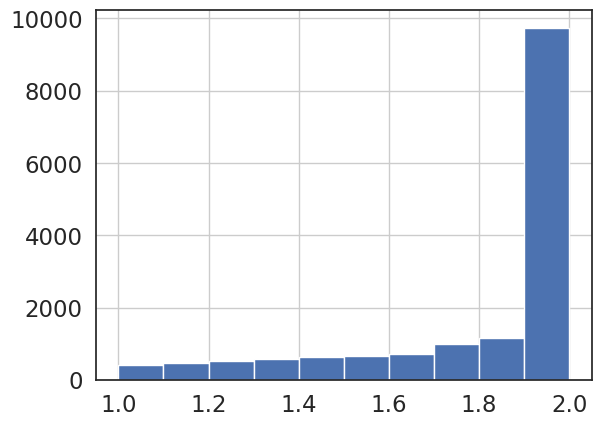

In [18]:
albf_scores.perplexity.hist()

In [19]:
# do junctions with higher difference simulated have lower perplexity?
# calculate pearson and spearman correlation
pearson_corr = stats.pearsonr(albf_scores["perplexity"], albf_scores["difference"])
spearman_corr = stats.spearmanr(albf_scores["perplexity"], albf_scores["difference"])

print(f"Pearson correlation between perplexity and simulated difference: {pearson_corr}")
print(f"Spearman correlation between perplexity and simulated difference: {spearman_corr}")

Pearson correlation between perplexity and simulated difference: PearsonRResult(statistic=-0.7993289592774466, pvalue=0.0)
Spearman correlation between perplexity and simulated difference: SignificanceResult(statistic=-0.8777382117598954, pvalue=0.0)


In [25]:
a / (a + b)

0.35076055

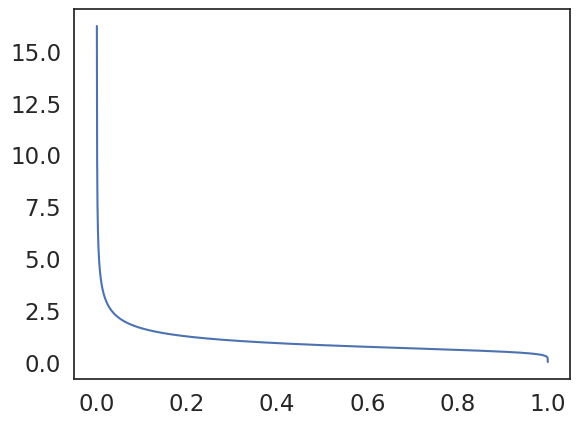

In [24]:
# The priors a and b are 0.5559861063957214 and 1.0212149620056152
# visualize beta distribution with a=0.56 and b=1.02

x = np.linspace(0, 1, 5000)
y = stats.beta.pdf(x, a, b)
plt.plot(x, y)

In [26]:
# let's get percentiles of ALBF values for calibration analysis of positive labels 
# find negative labels and their ALBF values percentiles for 0.5, 0.75, 0.8, 0.9, 0.95, 0.975, 0.99
percentiles = [0.5, 0.75, 0.8, 0.9, 0.95, 0.975, 0.99]
percentile_values = albf_scores[albf_scores["true_label"] == "negative"]["ALBF"].quantile(percentiles)

# let's set up a dictionary to keep track of the results for tp, fp, tn, fn, fdr, fnr at each percentile along with what the ALBF cutoff is
results = {}

for perc, albf in zip(percentiles, percentile_values):
    print(f"The {perc} percentile of ALBF values for negative labels is: {albf}")
    # make a new column for each percentile in albf_scores and calculate if ALBF is greater than the percentile value
    albf_scores[f"ALBF_{perc}"] = False
    albf_scores[f"ALBF_{perc}"] = albf_scores["ALBF"] >= albf

    # calculate the number of significant values, get "FDR"
    tp = albf_scores[(albf_scores["true_label"] == "positive") & (albf_scores[f"ALBF_{perc}"])].shape[0]
    fp = albf_scores[(albf_scores["true_label"] == "negative") & (albf_scores[f"ALBF_{perc}"])].shape[0]
    tn = albf_scores[(albf_scores["true_label"] == "negative") & (~albf_scores[f"ALBF_{perc}"])].shape[0]
    fn = albf_scores[(albf_scores["true_label"] == "positive") & (~albf_scores[f"ALBF_{perc}"])].shape[0]

    print(f"At {perc} percentile of ALBF values for negative labels, the expected FDR is {1-(perc):.2f}")
    print(f"At {perc} percentile of ALBF values for negative labels, number of true positives: {tp}, number of false positives: {fp}")

    fdr = fp / (fp + tp)
    fnr = fn / (fn + tp)

    print(f"At {perc} percentile of ALBF values for negative labels, False Discovery Rate: {fdr:.2f}")
    print(f"At {perc} percentile of ALBF values for negative labels, False Negative Rate: {fnr:.2f}")

    # save the results in the dictionary
    results[perc] = {"tp": tp, "fp": fp, "tn": tn, "fn": fn, "fdr": fdr, "fnr": fnr, "ALBF_cutoff": albf}
    print(f"-------------------------------------------------------------------------------------------------------------------------")


The 0.5 percentile of ALBF values for negative labels is: 0.0083847045
At 0.5 percentile of ALBF values for negative labels, the expected FDR is 0.50
At 0.5 percentile of ALBF values for negative labels, number of true positives: 5812, number of false positives: 5041
At 0.5 percentile of ALBF values for negative labels, False Discovery Rate: 0.46
At 0.5 percentile of ALBF values for negative labels, False Negative Rate: 0.00
-------------------------------------------------------------------------------------------------------------------------
The 0.75 percentile of ALBF values for negative labels is: 0.0561299325
At 0.75 percentile of ALBF values for negative labels, the expected FDR is 0.25
At 0.75 percentile of ALBF values for negative labels, number of true positives: 5812, number of false positives: 2521
At 0.75 percentile of ALBF values for negative labels, False Discovery Rate: 0.30
At 0.75 percentile of ALBF values for negative labels, False Negative Rate: 0.00
---------------

In [27]:
# convert the results dictionary to a dataframe
results_df = pd.DataFrame(results).T
results_df["negative_percentile"] = results_df.index
results_df

,tp,fp,tn,fn,fdr,fnr,ALBF_cutoff,negative_percentile
0.500,5812.0,5041.0,5041.0,0.0,0.464480,0.000000,0.008385,0.500
0.750,5812.0,2521.0,7561.0,0.0,0.302532,0.000000,0.056130,0.750
0.800,5812.0,2017.0,8065.0,0.0,0.257632,0.000000,0.165484,0.800
0.900,5719.0,1009.0,9073.0,93.0,0.149970,0.016001,2.561851,0.900
0.950,5281.0,505.0,9577.0,531.0,0.087280,0.091363,6.559346,0.950
0.975,4517.0,253.0,9829.0,1295.0,0.053040,0.222815,12.307026,0.975
0.990,3740.0,101.0,9981.0,2072.0,0.026295,0.356504,19.220247,0.990


(array([0.46447987, 0.3025321 , 0.25763188, 0.14997027, 0.08727964,
        0.05303983, 0.02629524]),
 [Text(0, 0.46447986731779234, '0.4645'),
  Text(0, 0.30253210128405134, '0.3025'),
  Text(0, 0.2576318814663431, '0.2576'),
  Text(0, 0.14997027348394767, '0.1500'),
  Text(0, 0.08727964051157967, '0.0873'),
  Text(0, 0.0530398322851153, '0.0530'),
  Text(0, 0.026295235615725072, '0.0263')])

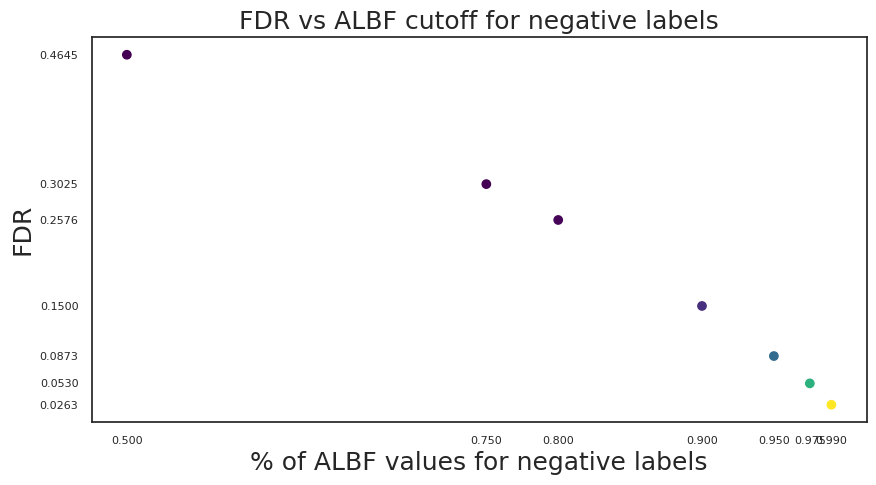

In [28]:
# plot percentiles of ALBF values for negative labels on x-axis and FDR on y-axis
plt.figure(figsize=(10, 5))
plt.scatter(results_df["negative_percentile"], results_df["fdr"], c=results_df["ALBF_cutoff"], cmap="viridis")
plt.xlabel("% of ALBF values for negative labels")
plt.ylabel("FDR")
plt.title("FDR vs ALBF cutoff for negative labels")

# show exact x-axis values and y-axis values that are in the dataframe
plt.xticks(results_df["negative_percentile"])
plt.yticks(results_df["fdr"])

# make font of all ticks smaller
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

(array([0.        , 0.        , 0.        , 0.01600138, 0.0913627 ,
        0.22281487, 0.35650379]),
 [Text(0, 0.0, '0.0000'),
  Text(0, 0.0, '0.0000'),
  Text(0, 0.0, '0.0000'),
  Text(0, 0.016001376462491397, '0.0160'),
  Text(0, 0.09136269786648314, '0.0914'),
  Text(0, 0.22281486579490709, '0.2228'),
  Text(0, 0.35650378527185134, '0.3565')])

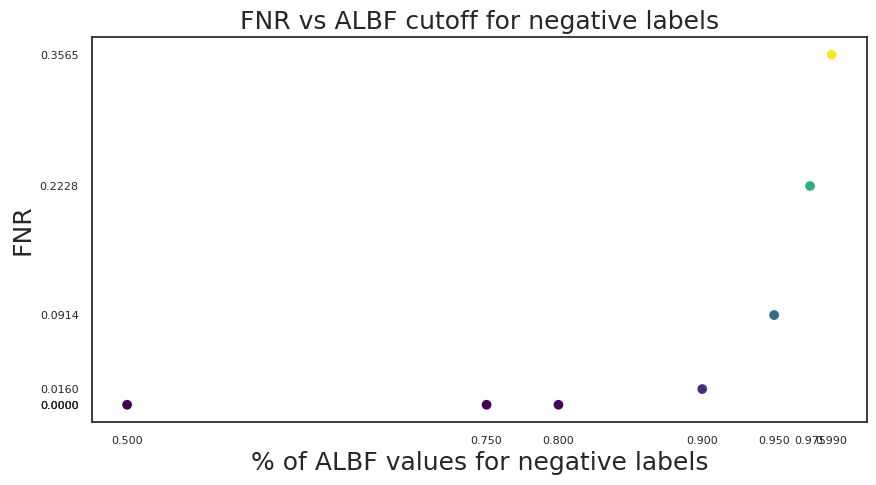

In [29]:
# plot percentiles of ALBF values for negative labels on x-axis and FDR on y-axis
plt.figure(figsize=(10, 5))
plt.scatter(results_df["negative_percentile"], results_df["fnr"], c=results_df["ALBF_cutoff"], cmap="viridis")
plt.xlabel("% of ALBF values for negative labels")
plt.ylabel("FNR")
plt.title("FNR vs ALBF cutoff for negative labels")

# show exact x-axis values and y-axis values that are in the dataframe
plt.xticks(results_df["negative_percentile"])
plt.yticks(results_df["fnr"])

# make font of all ticks smaller
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

In [30]:
def compute_fw_dss(albf_scores, pi_k, a_prior, b_prior):
    """
    Compute Factor-Weighted Differential Splicing Score (FW-DSS) for each junction.
    
    Parameters:
    - albf_scores (pd.DataFrame): DataFrame containing 'mu_k' and 'var_k' for each factor.
    - pi_k (np.array): Factor contributions (size K).
    - a_prior (float): Beta prior shape parameter a.
    - b_prior (float): Beta prior shape parameter b.
    
    Returns:
    - pd.Series: FW-DSS scores for each junction.
    """
    # Extract number of factors (K)
    K = len(pi_k)
    
    # Extract mu and variance columns dynamically
    mu_cols = [f"mu_{k}" for k in range(K)]
    var_cols = [f"loc_{k}" for k in range(K)]  # Assuming loc_k represents variance
    
    # Convert to numpy arrays for efficient computation
    mu_jk = albf_scores[mu_cols].to_numpy()  # (J x K)
    var_jk = albf_scores[var_cols].to_numpy()  # (J x K)
    
    # Compute weighted mean for each junction (J, )
    mu_avg_j = np.dot(mu_jk, pi_k)
    
    # Compute FW-DSS:
    # (1) Weighted variance term: How much junction varies across factors
    weighted_variance = np.sum(pi_k * (mu_jk - mu_avg_j[:, None])**2, axis=1)
    
    # (2) Weighted uncertainty: Variance term weighted by factor contributions
    weighted_uncertainty = np.sum(pi_k * var_jk, axis=1)
    
    # Combine terms
    fw_dss = weighted_variance + weighted_uncertainty

    # Normalize by prior a + b (optional)
    fw_dss /= (a_prior + b_prior)
    
    # Return as pandas Series
    return pd.Series(fw_dss, index=albf_scores.index, name="FW-DSS")

In [31]:
albf_scores["FW-DSS"] = compute_fw_dss(albf_scores, pis, a, b)

In [36]:
PSI_df.iloc[1324]

index                                        1
0                                     0.064039
1                                     0.999084
junction_id_index                         1324
junction_id          chr11_53774468_53775917_+
sample_label                          positive
Cluster                                  38339
difference                            0.935045
true_label                            positive
Name: 1324, dtype: object

In [32]:
albf_scores.sort_values(by="FW-DSS", ascending=False)

,latent_psi_1,latent_psi_2,entropy,perplexity,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,...,sigmoid_ALBF,posterior_probs,ALBF_0.5,ALBF_0.75,ALBF_0.8,ALBF_0.9,ALBF_0.95,ALBF_0.975,ALBF_0.99,FW-DSS
14906,0.060471,0.999993,0.218696,1.244453,1324,84.530120,0.935045,positive,38339,1,...,1.000000,1.000000e+00,True,True,True,True,True,True,True,30.227003
14645,0.046317,0.999976,0.181277,1.198747,12127,71.239730,0.949798,positive,21728,1,...,1.000000,1.000000e+00,True,True,True,True,True,True,True,29.670582
14263,0.000006,0.921484,0.000084,1.000084,12937,56.007720,0.918427,positive,24613,1,...,1.000000,1.000000e+00,True,True,True,True,True,True,True,29.179485
13531,0.000204,0.992830,0.001954,1.001955,10645,37.820477,0.988488,positive,19551,1,...,1.000000,9.999999e-01,True,True,True,True,True,True,True,27.640599
14200,0.000013,0.889561,0.000177,1.000177,3496,54.413620,0.887679,positive,48250,1,...,1.000000,1.000000e+00,True,True,True,True,True,True,True,25.576183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1580,0.484710,0.485502,0.693147,1.999999,13638,0.001287,0.000000,negative,26366,0,...,0.500322,3.971445e-10,False,False,False,False,False,False,False,0.000522
5481,0.449330,0.448535,0.693147,1.999999,5558,0.010574,0.000000,negative,56269,0,...,0.502644,4.008503e-10,True,False,False,False,False,False,False,0.000519
6120,0.241064,0.241684,0.693146,1.999998,5458,0.015381,0.000000,negative,55366,0,...,0.503845,4.027816e-10,True,False,False,False,False,False,False,0.000508
4720,0.378656,0.379678,0.693146,1.999998,5457,0.007263,0.000000,negative,55366,0,...,0.501816,3.995252e-10,False,False,False,False,False,False,False,0.000508


Text(0, 0.5, 'Frequency')

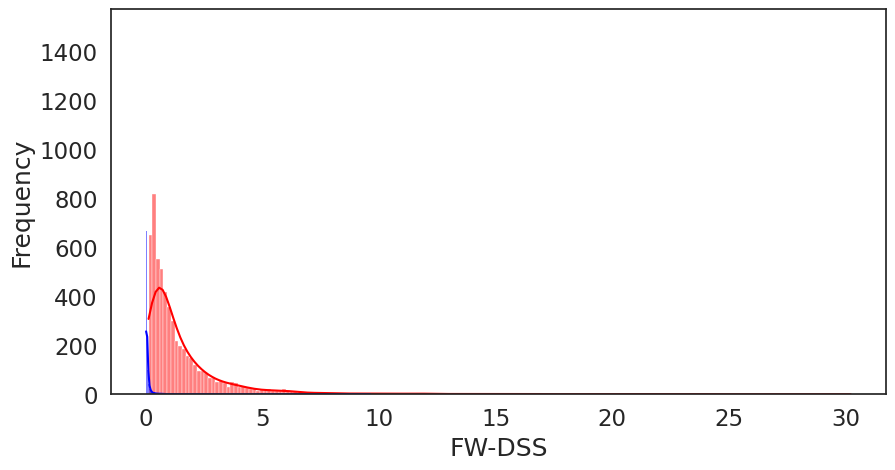

In [33]:
# plot distribution of FW-DSS scores for positive and negative labels
plt.figure(figsize=(10, 5))
sns.histplot(albf_scores[albf_scores["true_label"] == "positive"]["FW-DSS"], color="red", kde=True, label="Positive")
sns.histplot(albf_scores[albf_scores["true_label"] == "negative"]["FW-DSS"], color="blue", kde=True, label="Negative")
plt.xlabel("FW-DSS")
plt.ylabel("Frequency")

In [44]:
# what's the range of FW-DSS scores for positive and negative labels?
print(f"Range of FW-DSS scores for positive labels: {albf_scores[albf_scores['true_label'] == 'positive']['FW-DSS'].min()} - {albf_scores[albf_scores['true_label'] == 'positive']['FW-DSS'].max()}")
print(f"Range of FW-DSS scores for negative labels: {albf_scores[albf_scores['true_label'] == 'negative']['FW-DSS'].min()} - {albf_scores[albf_scores['true_label'] == 'negative']['FW-DSS'].max()}")

Range of FW-DSS scores for positive labels: 0.10554416892289747 - 30.22700279961072
Range of FW-DSS scores for negative labels: 0.00041573963622420563 - 9.609608822248942


In [48]:
PSI_df.iloc[6674]

index                                         2
0                                      0.000004
1                                      0.141311
junction_id_index                          6674
junction_id          chr1_156821464_156823990_-
sample_label                           positive
Cluster                                    2803
difference                             0.141307
true_label                             positive
Name: 6674, dtype: object

In [45]:
# what's min value of FW-DSS for positive labels?
albf_scores[albf_scores["true_label"] == "negative"].sort_values(by="FW-DSS")


,latent_psi_1,latent_psi_2,entropy,perplexity,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,...,sigmoid_ALBF,posterior_probs,ALBF_0.5,ALBF_0.75,ALBF_0.8,ALBF_0.9,ALBF_0.95,ALBF_0.975,ALBF_0.99,FW-DSS
6027,0.379709,0.379628,0.693147,2.000000,5459,0.014389,0.000000,negative,55366,0,...,0.503597,4.023823e-10,True,False,False,False,False,False,False,0.000416
4720,0.378656,0.379678,0.693146,1.999998,5457,0.007263,0.000000,negative,55366,0,...,0.501816,3.995252e-10,False,False,False,False,False,False,False,0.000508
6120,0.241064,0.241684,0.693146,1.999998,5458,0.015381,0.000000,negative,55366,0,...,0.503845,4.027816e-10,True,False,False,False,False,False,False,0.000508
5481,0.449330,0.448535,0.693147,1.999999,5558,0.010574,0.000000,negative,56269,0,...,0.502644,4.008503e-10,True,False,False,False,False,False,False,0.000519
1580,0.484710,0.485502,0.693147,1.999999,13638,0.001287,0.000000,negative,26366,0,...,0.500322,3.971445e-10,False,False,False,False,False,False,False,0.000522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11479,0.106067,0.000121,0.008866,1.008905,221,14.550323,0.100551,negative,37385,1,...,1.000000,8.263347e-04,True,True,True,True,True,True,False,8.621288
11254,0.000032,0.133745,0.002238,1.002240,6672,13.103170,0.141307,negative,2803,1,...,0.999998,1.945090e-04,True,True,True,True,True,True,False,8.720942
11540,0.000050,0.149027,0.003003,1.003007,6674,15.127007,0.141307,negative,2803,1,...,1.000000,1.470031e-03,True,True,True,True,True,True,False,8.984284
11613,0.000096,0.116554,0.006686,1.006709,10259,15.659878,0.113002,negative,12026,1,...,1.000000,2.502076e-03,True,True,True,True,True,True,False,9.514244


The means are: tensor([-9.6681, -1.7513], dtype=torch.float64)
The variances are: tensor([1.0411, 0.0314], dtype=torch.float64)
The combined mean is: -1.9824038743972778
The combined variance is: 0.06088684871792793
The means are: [-9.668141, -1.7513295, -1.9824038743972778]
The variances are: [1.0411482, 0.03141495, 0.06088684871792793]
The mean of the sampled PSI values is: 0.0001150980680672113
The mean of the sampled PSI values is: 0.13141611068349826
The mean of the sampled PSI values is: 0.11272781450310473


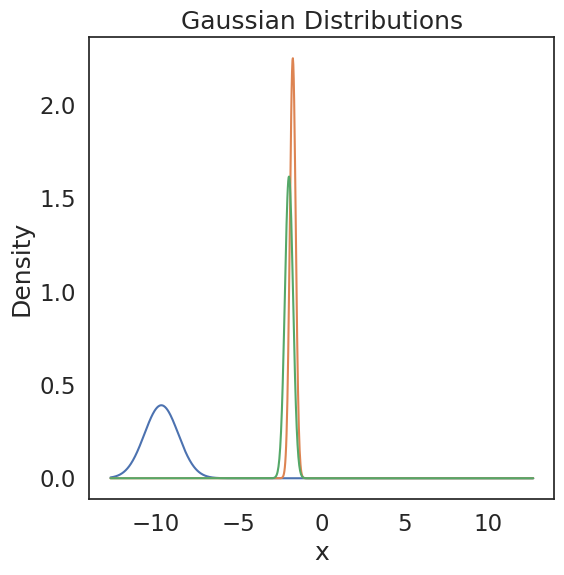

In [50]:
plot_junc_dists(albf_scores, 11540, pis)